In [1]:
# pip install kaggle

In [85]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report,accuracy_score,confusion_matrix,roc_auc_score,average_precision_score,precision_score,recall_score,f1_score

In [3]:
import kaggle

In [4]:
# kaggle.api.dataset_download_files(
#     "ealaxi/paysim1",
#     path="data",
#     unzip=True
# )

In [5]:
import os

os.listdir("data")

['PS_20174392719_1491204439457_log.csv']

In [6]:
df = pd.read_csv(
    "data/PS_20174392719_1491204439457_log.csv"
)

df.head()


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [7]:
df['step'].value_counts()

step
19     51352
18     49579
187    49083
235    47491
307    46968
       ...  
432        4
706        4
693        4
112        2
662        2
Name: count, Length: 743, dtype: int64

## Build an end-to-end machine learning system that can detect fraudulent digital payment transactions in real time with high recall, while minimizing false alarms, to reduce financial losses and protect customers

### Phase 1: Data Understanding & Business Context

<!-- Column               	Meaning
step	                Time step (hour-based)
type	                Transaction type (TRANSFER, CASH_OUT, PAYMENT, etc.)
amount              	Transaction amount
nameOrig            	Sender ID
oldbalanceOrg	        Sender balance before
newbalanceOrig	        Sender balance after
nameDest	            Receiver ID
oldbalanceDest	        Receiver balance before
newbalanceDest	        Receiver balance after
isFraud              	1 = Fraud, 0 = Normal
isFlaggedFraud	        System-flagged fraud -->

In [11]:
df.shape

(6362620, 11)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [13]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [14]:
df['isFraud'].value_counts(normalize=True)

isFraud
0    0.998709
1    0.001291
Name: proportion, dtype: float64

In [15]:
df['type'].value_counts()

type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64

In [16]:
df[df['isFraud']==1]['type'].value_counts()     #we can understand for which type fraud is haapened

type
CASH_OUT    4116
TRANSFER    4097
Name: count, dtype: int64

In [17]:
df[df['isFlaggedFraud']==1]['type'].value_counts()     #we can understand for which type fraud is system flagged fraud

type
TRANSFER    16
Name: count, dtype: int64

### EDA

In [19]:
df[df['isFraud']==1]['amount'].mean()           #here we can understand when fraud has happend what was avg transactional amount 

1467967.299140387

C:\Users\Rahul\AppData\Local\Temp\ipykernel_20028\4007363158.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df,x='type',palette='coolwarm')


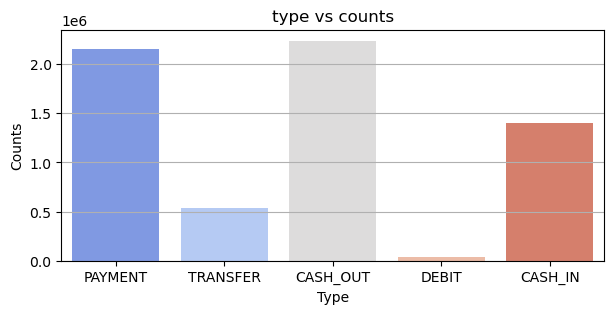

In [20]:
plt.figure(figsize=(7,3))
plt.title('type vs counts')
sns.countplot(data=df,x='type',palette='coolwarm')
plt.xlabel('Type')
plt.ylabel('Counts')
plt.grid(axis='y', alpha=1)
plt.show()

In [21]:
df['org_diff'] = df['oldbalanceOrg'] - df['newbalanceOrig']
df['dest_diff'] = df['newbalanceDest'] - df['oldbalanceDest']

In [22]:
fraud = df[df['isFraud'] == 1]
normal = df[df['isFraud'] == 0]

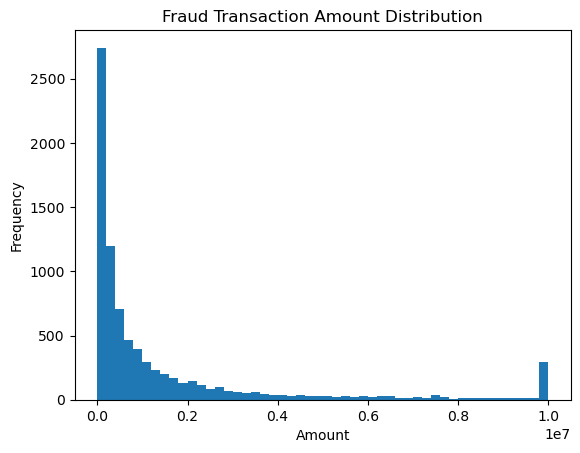

In [23]:
plt.hist(fraud['amount'], bins=50)
plt.title("Fraud Transaction Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.show()

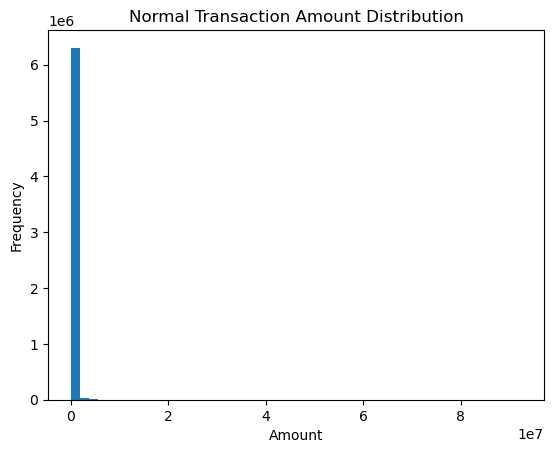

In [24]:
plt.hist(normal['amount'], bins=50)
plt.title("Normal Transaction Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.show()

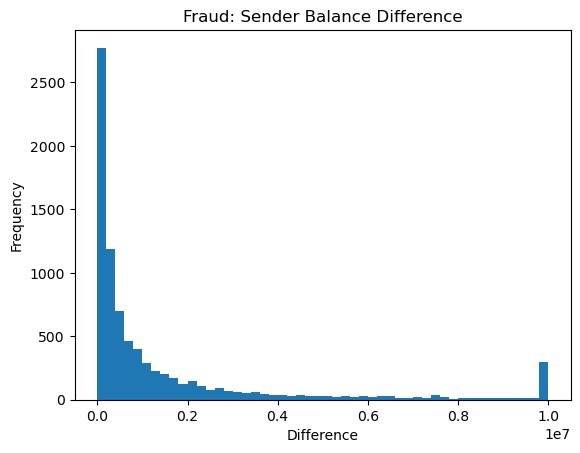

In [25]:
plt.hist(fraud['org_diff'], bins=50)
plt.title("Fraud: Sender Balance Difference")
plt.xlabel("Difference")
plt.ylabel("Frequency")
plt.show()

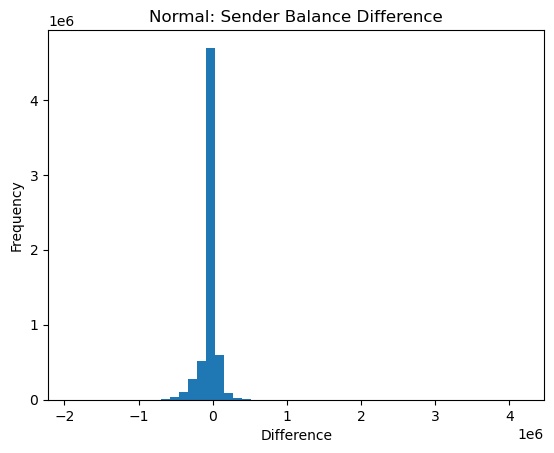

In [26]:
plt.hist(normal['org_diff'], bins=50)
plt.title("Normal: Sender Balance Difference")
plt.xlabel("Difference")
plt.ylabel("Frequency")
plt.show()

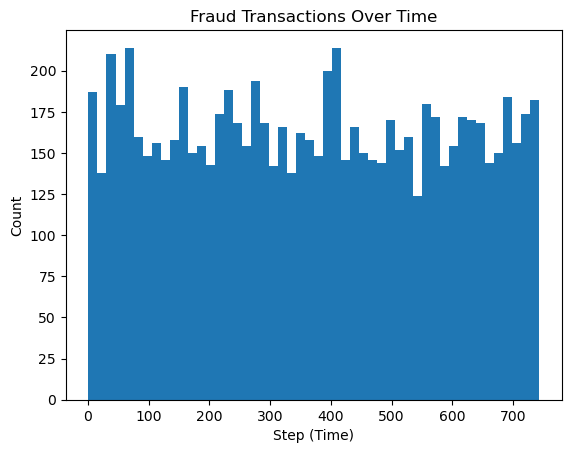

In [27]:
plt.hist(fraud['step'], bins=50)
plt.title("Fraud Transactions Over Time")
plt.xlabel("Step (Time)")
plt.ylabel("Count")
plt.show()

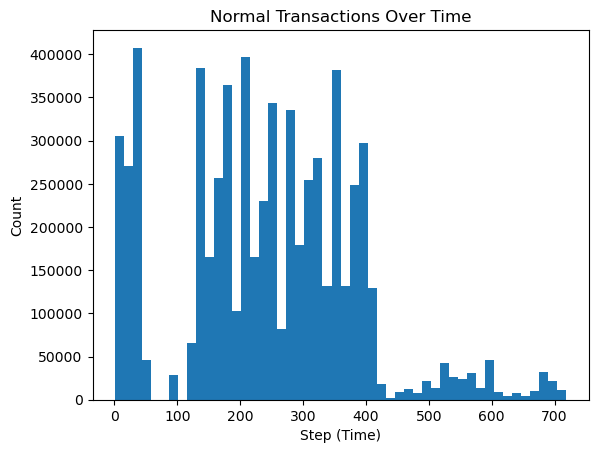

In [28]:
plt.hist(normal['step'], bins=50)
plt.title("Normal Transactions Over Time")
plt.xlabel("Step (Time)")
plt.ylabel("Count")
plt.show()

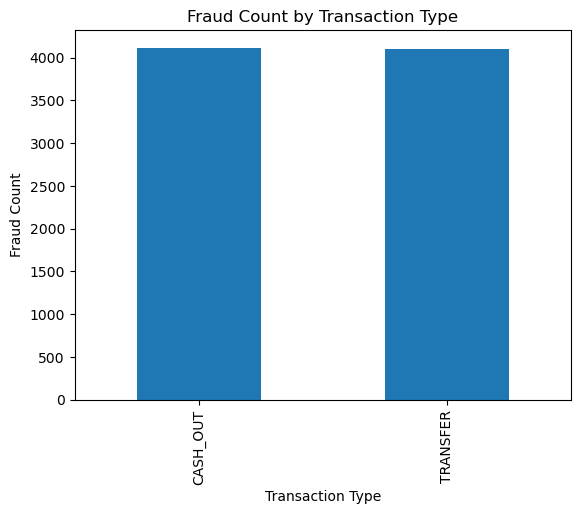

In [29]:
fraud_types = fraud['type'].value_counts()

fraud_types.plot(kind='bar')
plt.title("Fraud Count by Transaction Type")
plt.xlabel("Transaction Type")
plt.ylabel("Fraud Count")
plt.show()

In [30]:
print("Fraud Amount Stats:")
print(fraud['amount'].describe())

print("\nNormal Amount Stats:")
print(normal['amount'].describe())

Fraud Amount Stats:
count    8.213000e+03
mean     1.467967e+06
std      2.404253e+06
min      0.000000e+00
25%      1.270913e+05
50%      4.414234e+05
75%      1.517771e+06
max      1.000000e+07
Name: amount, dtype: float64

Normal Amount Stats:
count    6.354407e+06
mean     1.781970e+05
std      5.962370e+05
min      1.000000e-02
25%      1.336840e+04
50%      7.468472e+04
75%      2.083648e+05
max      9.244552e+07
Name: amount, dtype: float64


### Feature Engineering & Data Preparation

In [32]:
df['balance_ratio'] = df['amount'] / (df['oldbalanceOrg'] + 1)

In [33]:
X = df[['type','amount','oldbalanceOrg','newbalanceOrig','oldbalanceDest','newbalanceDest','org_diff','dest_diff']]
y = df['isFraud']

In [34]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3, random_state=45,stratify=y)

In [35]:
cat_cols = ['type']
num_cols = [col for col in X.columns if col not in cat_cols]

In [36]:
one = OneHotEncoder(drop='first',sparse_output=False)

In [37]:
X_train_cat = one.fit_transform(X_train[cat_cols])
X_test_cat = one.transform(X_test[cat_cols])

In [38]:
encoded_cols = one.get_feature_names_out(cat_cols)

In [39]:
X_train_cat_df = pd.DataFrame(
    X_train_cat,
    columns=encoded_cols,
    index=X_train.index
)

X_test_cat_df = pd.DataFrame(
    X_test_cat,
    columns=encoded_cols,
    index=X_test.index
)

In [40]:
X_train_num = X_train[num_cols]
X_test_num = X_test[num_cols]
X_train_final = pd.concat([X_train_num, X_train_cat_df], axis=1)
X_test_final = pd.concat([X_test_num, X_test_cat_df], axis=1)

In [41]:
X_train_final

,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,org_diff,dest_diff,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
1659609,7142.20,9841.86,2699.66,0.00,0.00,7142.20,0.00,0.0,0.0,1.0,0.0
1310833,198687.37,0.00,0.00,2352846.20,2551533.56,0.00,198687.36,1.0,0.0,0.0,0.0
6270143,445056.86,0.00,0.00,18080978.80,18526035.66,0.00,445056.86,0.0,0.0,0.0,1.0
3469558,162875.00,71.00,0.00,1178276.36,1341151.36,71.00,162875.00,1.0,0.0,0.0,0.0
5850672,179742.77,1946244.55,2125987.32,366786.97,187044.20,-179742.77,-179742.77,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
154759,129454.57,10494.00,139948.57,294090.33,164635.76,-129454.57,-129454.57,0.0,0.0,0.0,0.0
2080899,72229.96,9698118.16,9770348.11,76216.77,3986.82,-72229.95,-72229.95,0.0,0.0,0.0,0.0
6231246,360247.17,0.00,0.00,9483131.84,9843379.01,0.00,360247.17,0.0,0.0,0.0,1.0
2407405,8500.37,110024.45,101524.09,0.00,0.00,8500.36,0.00,0.0,0.0,1.0,0.0


### Build Model
Logistic Regression

In [43]:
lr = LogisticRegression(class_weight='balanced',max_iter=1000)

In [44]:
lr.fit(X_train_final,y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [45]:
print(classification_report(y_test,lr.predict(X_test_final)))

              precision    recall  f1-score   support

           0       1.00      0.96      0.98   1906322
           1       0.03      0.87      0.06      2464

    accuracy                           0.96   1908786
   macro avg       0.52      0.92      0.52   1908786
weighted avg       1.00      0.96      0.98   1908786



In [46]:
y_prob = lr.predict_proba(X_test_final)[:,1]

In [47]:
for t in [0.2, 0.3, 0.4, 0.5, 0.6, 0.7]:
    y_pred_custom = (y_prob >= t).astype(int)
    print(f"\nThreshold = {t}")
    print(classification_report(y_test, y_pred_custom))


Threshold = 0.2
              precision    recall  f1-score   support

           0       1.00      0.90      0.95   1906322
           1       0.01      0.98      0.03      2464

    accuracy                           0.90   1908786
   macro avg       0.51      0.94      0.49   1908786
weighted avg       1.00      0.90      0.95   1908786


Threshold = 0.3
              precision    recall  f1-score   support

           0       1.00      0.94      0.97   1906322
           1       0.02      0.94      0.04      2464

    accuracy                           0.94   1908786
   macro avg       0.51      0.94      0.50   1908786
weighted avg       1.00      0.94      0.97   1908786


Threshold = 0.4
              precision    recall  f1-score   support

           0       1.00      0.96      0.98   1906322
           1       0.03      0.90      0.05      2464

    accuracy                           0.96   1908786
   macro avg       0.51      0.93      0.51   1908786
weighted avg       1.00

#### Model 2 Random forest

In [49]:
rf = RandomForestClassifier(n_estimators=100,max_depth=15,class_weight="balanced",random_state=45,n_jobs=-1)

In [50]:
rf.fit(X_train_final,y_train)

RandomForestClassifier(class_weight='balanced', max_depth=15, n_jobs=-1,
                       random_state=45)

In [51]:
y_pred=rf.predict(X_test_final)

In [52]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1906322
           1       0.35      0.97      0.52      2464

    accuracy                           1.00   1908786
   macro avg       0.68      0.99      0.76   1908786
weighted avg       1.00      1.00      1.00   1908786



In [53]:
confusion_matrix(y_test,rf.predict(X_test_final))

array([[1901951,    4371],
       [     66,    2398]], dtype=int64)

In [54]:
len(set(X_train_final.index).intersection(set(X_test_final.index)))

0

In [55]:
'isFlaggedFraud' in X_train_final.columns

False

In [56]:
for col in X_train_final.columns:
    print(col, X_train_final[col].corr(y_train))

amount 0.07680069094923953
oldbalanceOrg 0.010025052869626525
newbalanceOrig -0.008296709924252308
oldbalanceDest -0.006154549995608048
newbalanceDest 0.000396809177191428
org_diff 0.3623614121093691
dest_diff 0.027244205352820954
type_CASH_OUT 0.010982661424909874
type_DEBIT -0.0029176639550227315
type_PAYMENT -0.025695010770715582
type_TRANSFER 0.054342420194252665


In [57]:
pd.crosstab(
    df['isFraud'],
    (df['oldbalanceDest']==0) & (df['newbalanceDest']==0)
)

col_0,False,True
isFraud,,
0,4041201,2313206
1,4137,4076


In [58]:
print(X_train_final.shape, X_test_final.shape)
print(y_train.value_counts())
print(y_test.value_counts())

(4453834, 11) (1908786, 11)
isFraud
0    4448085
1       5749
Name: count, dtype: int64
isFraud
0    1906322
1       2464
Name: count, dtype: int64


In [59]:
scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])

In [60]:
xgb = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    n_estimators=200,
    max_depth=6,
    learning_rate=0.01,
    random_state=45,
    n_jobs=-1)

In [61]:
xgb.fit(X_train_final, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.01, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=-1, num_parallel_tree=None, ...)

In [62]:
y_pred = xgb.predict(X_test_final)
y_prob = xgb.predict_proba(X_test_final)[:,1]

In [63]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nROC-AUC Score:")
print(roc_auc_score(y_test, y_prob))

Confusion Matrix:
[[1882072   24250]
 [      8    2456]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99   1906322
           1       0.09      1.00      0.17      2464

    accuracy                           0.99   1908786
   macro avg       0.55      0.99      0.58   1908786
weighted avg       1.00      0.99      0.99   1908786


ROC-AUC Score:
0.998878935679323


In [64]:
param_grid = {
    'max_depth': [4,5,6,7,8],
    'learning_rate': [0.01,0.05,0.1],
    'n_estimators': [150,200,300],
    'subsample': [0.7,0.8,0.9],
    'colsample_bytree': [0.7,0.8,0.9],
    'min_child_weight': [1,3,5],
    'gamma': [0,1,2]
}

In [65]:
xgb = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    eval_metric='auc',
    random_state=45,
    n_jobs=-1
)

In [66]:
random_search = RandomizedSearchCV(
    xgb,
    param_grid,
    n_iter=10,      
    cv=3,
    verbose=2,
    n_jobs=-1
)

In [67]:
# random_search.fit(X_train_final, y_train)

In [68]:
sample_idx = X_train_final.sample(300000, random_state=45).index
X_sample = X_train_final.loc[sample_idx]
y_sample = y_train.loc[sample_idx]

In [69]:
random_search.fit(X_sample, y_sample)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


RandomizedSearchCV(cv=3,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric='auc',
                                           feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_constrai...
                                           min_child_weight=None, missing=nan,
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=-1,
                                           num_parallel_tree=None, ...),
                   n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.7, 0.8, 0.9],
                                        'gamma': [0, 1, 2],
                                        'learning_rate': [0.01, 0.05, 0.1],
                                        'max_depth': [4, 5, 6, 7, 8],
                                        'min_child_weight': [1, 3, 5],
                                        'n_estimators': [150, 200, 300],
                                        'subsample': [0.7, 0.8, 0.9]},
                   verbose=2)

In [70]:
best_params = random_search.best_params_
best_params

{'subsample': 0.7,
 'n_estimators': 300,
 'min_child_weight': 1,
 'max_depth': 6,
 'learning_rate': 0.05,
 'gamma': 2,
 'colsample_bytree': 0.7}

In [71]:
print(random_search.best_score_)

0.9987033333333334


In [72]:
final_model = XGBClassifier(
    **best_params,
    scale_pos_weight=scale_pos_weight,
    random_state=45,
    n_jobs=-1
)
final_model.fit(X_train_final, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.7, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=2, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=1, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=-1, num_parallel_tree=None, ...)

In [73]:
y_pred = final_model.predict(X_test_final)

In [74]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[1898594    7728]
 [     14    2450]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1906322
           1       0.24      0.99      0.39      2464

    accuracy                           1.00   1908786
   macro avg       0.62      1.00      0.69   1908786
weighted avg       1.00      1.00      1.00   1908786



In [75]:
y_prob = final_model.predict_proba(X_test_final)[:,1]

In [76]:
thresholds = [0.5,0.6,0.7,0.8,0.9]
for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)
    print("\nThreshold:", t)
    print(classification_report(y_test, y_pred_t))


Threshold: 0.5
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1906322
           1       0.24      0.99      0.39      2464

    accuracy                           1.00   1908786
   macro avg       0.62      1.00      0.69   1908786
weighted avg       1.00      1.00      1.00   1908786


Threshold: 0.6
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1906322
           1       0.28      0.99      0.43      2464

    accuracy                           1.00   1908786
   macro avg       0.64      1.00      0.72   1908786
weighted avg       1.00      1.00      1.00   1908786


Threshold: 0.7
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1906322
           1       0.32      0.99      0.48      2464

    accuracy                           1.00   1908786
   macro avg       0.66      1.00      0.74   1908786
weighted avg       1.00   

### Smote + Xgboost


In [78]:
from imblearn.over_sampling import SMOTE

In [91]:
def train_xgb_smote(df, feature_cols, target_col='isFraud', test_size=0.2, random_state=42,
                    smote_ratio=0.10, threshold=0.50):
    """
    Train XGBoost on SMOTE-resampled training data and evaluate on test data.
    """

    data = df.copy()

    X = data[feature_cols]
    y = data[target_col]

    X = pd.get_dummies(X, columns=['type'], drop_first=True)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=test_size,
        stratify=y,
        random_state=random_state
    )

    smote = SMOTE(sampling_strategy=smote_ratio, random_state=random_state, k_neighbors=5)
    X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

    model = XGBClassifier(
        objective='binary:logistic',
        eval_metric='aucpr',
        n_estimators=600,
        learning_rate=0.03,
        max_depth=4,
        min_child_weight=8,
        subsample=0.8,
        colsample_bytree=0.8,
        gamma=1,
        reg_alpha=1.0,
        reg_lambda=5.0,
        tree_method='hist',
        random_state=random_state,
        n_jobs=-1
    )

    model.fit(X_train_res, y_train_res)

    # predictions
    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)

    # metrics
    results = {
        "roc_auc": roc_auc_score(y_test, y_prob),
        "pr_auc": average_precision_score(y_test, y_prob),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "confusion_matrix": confusion_matrix(y_test, y_pred),
        "classification_report": classification_report(y_test, y_pred, zero_division=0)
    }

    return model, results, X_train.columns

In [87]:
features_model_1 = [
    'type',
    'amount',
    'oldbalanceOrg',
    'newbalanceOrig',
    'oldbalanceDest',
    'newbalanceDest',
    'org_diff',
    'dest_diff'
]

model_1, results_1, cols_1 = train_xgb_smote(
    df=df,
    feature_cols=features_model_1,
    smote_ratio=0.10,
    threshold=0.50
)

print("MODEL 1 - WITHOUT balance_ratio")
print("ROC-AUC:", results_1["roc_auc"])
print("PR-AUC:", results_1["pr_auc"])
print("Precision:", results_1["precision"])
print("Recall:", results_1["recall"])
print("F1:", results_1["f1"])
print("Confusion Matrix:\n", results_1["confusion_matrix"])
print(results_1["classification_report"])

MODEL 1 - WITHOUT balance_ratio
ROC-AUC: 0.9996479292327988
PR-AUC: 0.9265807826990581
Precision: 0.30851063829787234
Recall: 0.9884357881923311
F1: 0.47024757492399016
Confusion Matrix:
 [[1267241    3640]
 [     19    1624]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.31      0.99      0.47      1643

    accuracy                           1.00   1272524
   macro avg       0.65      0.99      0.73   1272524
weighted avg       1.00      1.00      1.00   1272524



In [89]:
df["balance_ratio"] = df["amount"] / (df["oldbalanceOrg"] + 1)

features_model_2 = [
    'type',
    'amount',
    'oldbalanceOrg',
    'newbalanceOrig',
    'oldbalanceDest',
    'newbalanceDest',
    'org_diff',
    'dest_diff',
    'balance_ratio'
]

model_2, results_2, cols_2 = train_xgb_smote(
    df=df,
    feature_cols=features_model_2,
    smote_ratio=0.10,
    threshold=0.50
)

print("MODEL 2 - WITH balance_ratio")
print("ROC-AUC:", results_2["roc_auc"])
print("PR-AUC:", results_2["pr_auc"])
print("Precision:", results_2["precision"])
print("Recall:", results_2["recall"])
print("F1:", results_2["f1"])
print("Confusion Matrix:\n", results_2["confusion_matrix"])
print(results_2["classification_report"])

MODEL 2 - WITH balance_ratio
ROC-AUC: 0.9996381014382256
PR-AUC: 0.9986093526158971
Precision: 0.9328400682982356
Recall: 0.9975654290931223
F1: 0.9641176470588235
Confusion Matrix:
 [[1270763     118]
 [      4    1639]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.93      1.00      0.96      1643

    accuracy                           1.00   1272524
   macro avg       0.97      1.00      0.98   1272524
weighted avg       1.00      1.00      1.00   1272524

